# Milestone 3: Baseline Modeling

## Detection of Hydroxychloroquine Macular Toxicity via OCT Images

Proyecto Integrador - TC5035.10

Team 45

Tecnológico de Monterrey

Sponsor: Dr. Alejandro Rodríguez García, Hospital Zambrano Hellion
Date: May 2026

Team members:

- Natalia Nevarez Tinoco - A01566204

- Alejandro Caamaño Granados - A00843392

- Diana Jimena López Nájera - A01024913

## 0. Google Drive Setup

The M2 export (`OCT_Dataset_Limpio_cropped`) is the direct input of this notebook.

In [1]:
from google.colab import drive
import os
from pathlib import Path

drive.mount('/content/drive')

# Locate the Milestone 2 processed-image export anywhere in Drive.
# Expected structure: <something>/OCT_Dataset_Limpio_cropped/{No,Si,Sospecha}
EXPECTED = ('/content/drive/MyDrive/Colab Notebooks/MNA/'
            'Proyecto Integrador/Avance3/OCT_Dataset_Limpio_cropped')

data_root = None
if Path(EXPECTED).exists():
  data_root = Path(EXPECTED)
else:
  # Fallback: search, but prefer a path containing 'Avance3'
    matches = []
    for root, dirs, files in os.walk('/content/drive/MyDrive', followlinks=True):
        if Path(root).name == 'OCT_Dataset_Limpio_cropped':
            dirs_low = [d.lower() for d in dirs]
            if 'no' in dirs_low and 'si' in dirs_low:
                matches.append(Path(root))
    # Prefer the Avance3 copy if multiple exist
    for m in matches:
        if 'Avance3' in str(m):
            data_root = m
            break
    if data_root is None and matches:
        data_root = matches[0]

if data_root is not None:
  actual = {d.lower(): d for d in os.listdir(data_root)}
  NO_DIR = data_root / actual['no']
  SI_DIR = data_root / actual['si']
  print(f'Processed dataset found at: {data_root}')
  print(f'  No: {len(list(NO_DIR.iterdir()))} files')
  print(f'  Si: {len(list(SI_DIR.iterdir()))} files')
else:
  print("ERROR: dataset not found.")

# Locate the HCQuery pre trained model
# Upload hcquery_model.pt to your Drive and set the path below
HCQUERY_MODEL_PATH = ('/content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Avance3/hcquery_model.pt')

if Path (HCQUERY_MODEL_PATH).exists():
  print(f'HCQuery model found: {HCQUERY_MODEL_PATH}')
  HCQ_AVAILABLE = True
else:
  print(f'ERROR: HCQuery model not found at {HCQUERY_MODEL_PATH}')
  print(f'Upload it to Drive and update HCQUERY_MODEL_PATH above.')
  HCQ_AVAILABLE = False

Mounted at /content/drive
Processed dataset found at: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Avance3/OCT_Dataset_Limpio_cropped
  No: 179 files
  Si: 15 files
HCQuery model found: /content/drive/MyDrive/Colab Notebooks/MNA/Proyecto Integrador/Avance3/hcquery_model.pt


## 1. Import Libraries

The modeling phase introuces libraries beyond those used for data preparation:

- `torch`/`torchvision` - the CNN baseline, transfer learning backbone, augmentation pipeline, and training loop.
- `scikit-learn` - the classical baseline models (`DummyClassifier`, `LogisticRegression`, `RandomForestClassifier`), the patient level splitter (`StratifiedGroupKFold`), and all evaluation metrics.
- `skimage.feature.hog` - recomputes the HOG descriptors from M2 Section 3.3, si this notebook is self contained.
- `matplotlib`/`seaborn` - confusion matrices, precision recall curves, and learning curves.

In [2]:
import glob, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import random
import os

from skimage import io
from skimage.feature import hog

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    roc_auc_score, recall_score, precision_score,
    f1_score, fbeta_score
)


import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.transforms import v2

# HCQuery uses the efficientnet_pytorch library
try:
    from efficientnet_pytorch import EfficientNet
    print("efficientnet_pytorch already installed.")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                           'efficientnet_pytorch', '-q'])
    from efficientnet_pytorch import EfficientNet
    print("efficientnet_pytorch installed.")

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Libraries imported. Compute device: {DEVICE}')

efficientnet_pytorch installed.
Libraries imported. Compute device: cuda


## 2. Load Preprocessed Image Dataset

Milestone 2 exported every OCT scan as a fovea-centered, CLAHE-normalized 224x224 grayscale PNG. This section builds an index dataframe of those files. The `Sospecha` (suspected) class is excluded - the project target is the binary No vs Si problem.

Two columns matter beyond the file path and label:

- `patient_id` - parsed from the file name, exactly as in Mileston 2 Section 4. This is never a model feature; it is used only to keep all scans from one patient inside a single train/validation/test split.
- `label` - the binary target, `no` (0) or `si` (1)

In [3]:
def parse_patient_id(filepath):
  '''Patient ID is the first underscore-separated token
  of the filename, matching M2 filename parser.'''
  stem = Path(filepath).stem
  parts = stem.split('_')
  if stem.startswith('AUTO') and len(parts) > 1:
    return parts[1]
  return parts[0]

records = []
for label_dir, label in [(NO_DIR, 'no'), (SI_DIR, 'si')]:
  for fp in label_dir.iterdir():
    if fp.suffix.lower() in ('.png', '.jpg', '.jpeg'):
      records.append({
          'filepath': str(fp),
          'label': label,
          'label_enc': 0 if label == 'no' else 1,
          'patient_id': parse_patient_id(fp),
      })

df = pd.DataFrame(records).reset_index(drop=True)
print(f'Total processed images: {len(df)}')
print(df['label'].value_counts().rename('count'))
print(f'Unique patients: {df['patient_id'].nunique()}')

Total processed images: 194
label
no    179
si     15
Name: count, dtype: int64
Unique patients: 69


### 2.1 Confirming Class Imbalance

The class distribution is printed and visualized. The 12:1 imbalance carried from M1 is the single most important fact for the modeling phase: it dictates the choice of evaluation metric (Section 3), the choice of loss function, and the interpretation of every result.

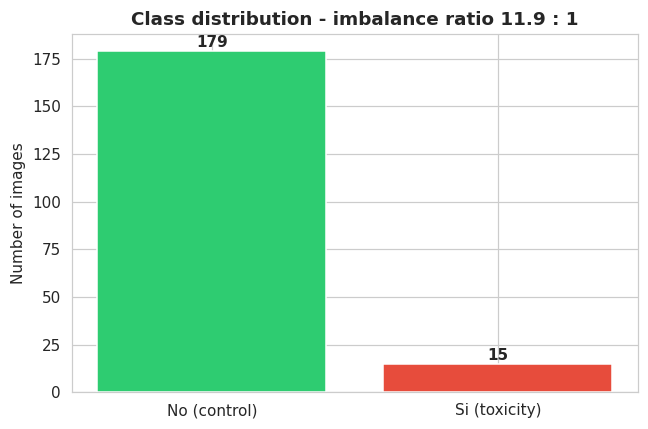

Si prevalence (positive-class base rate): 0.0773
A classifier predicting "No" for everything would score 92.3% accuracy while detecting zero toxicity cases.


In [4]:
counts = df['label'].value_counts()
imbalance_ratio = counts['no'] / counts['si']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['No (control)', 'Si (toxicity)'],
              [counts['no'], counts['si']],
              color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_ylabel('Number of images')
ax.set_title(f'Class distribution - imbalance ratio {imbalance_ratio:.1f} : 1',
             fontweight='bold')
for b, c in zip(bars, [counts['no'], counts['si']]):
    ax.text(b.get_x() + b.get_width()/2, c + 2, str(c),
            ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

si_prevalence = counts['si'] / len(df)
print(f'Si prevalence (positive-class base rate): {si_prevalence:.4f}')
print(f'A classifier predicting "No" for everything would score '
      f'{counts["no"]/len(df):.1%} accuracy while detecting zero toxicity cases.')

## 3. Modeling Startetgy

### 3.1 A Tiered Baseline

*What alforithm can serve as a baseline?*

Three tiers will be built, each testing a different hypothesis.

| Tier | Model | Input | Hypothesis it tests |
|---|---|---|---|
| **0 - Trivial** | Majority-class and stratified-random `DummyClassifier` | none (label statistics only) | Defines the *floor*. Any real model must beat this. |
| **1 - Classical** | Logistic Regression, Random Forest | HOG -> PCA features from Milestone 2 | Do *hand-crafted* texture features carry a learnable signal? |
| **2 - Deep learning** | Transfer-learning CNN (frozen ResNet18 backbone) | raw 224x224 pixels | Do *learned* features beat hand-crafted ones? |

Tier 0 is essential and often skipped: with a 12:1 imbalance the majority classifier reaches ~92% accuracy while being clinically useless. That single result is the empirical argument for why accuracy is the wrong metric. Tier 1 directly reuses the HOG/PCA deliverable from Milestone 2 Section 7. Tier 2 is the genuine reference point for the final model of Milestone 4.

We establish the absolute statistical floor of our class imbalance by training a control baseline `DummyClassifier`, which simply predicts the majority class (No). The second tier introduces classical linear and tree-based ensembles (LogisticRegression and RandomForestClassifier) trained on handcrafted geometric features extracted via HOG (Histogram of Oriented Gradients).

In [5]:
RANDOM_STATE = 42


dummy_baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

logistic_baseline = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)

rf_baseline = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=RANDOM_STATE)

### 3.2 Evaluation Protocol: Parient-Level Splitting

To prevent artificial inflation of performance metrics, the dataset is partitioned strictly along patient boundaries. Because a single individual can have multiple OCT scans, simple random splitting would cause identical tissue characteristics to appear in both training and test sets.

- Patient ID Extraction (parse_patient_id): Isolates the patient identifier from file stems to keep all related scans bound together during dataset operations.

- Stratified Group K-Fold (StratifiedGroupKFold): Enforces a cross-validation scheme where all images belonging to a specific patient are isolated to a single fold, ensuring that validation data is completely unseen by the model while maintaining global class distribution ratios.

In [6]:
def parse_patient_id(filepath):
    return os.path.basename(filepath).split('_')[0]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 3.3 Right Metrics

**The business problem defines the metric.** This is a *screening* tool for drug-induced toxicity. The two error types are not symmetric:

- A **false negative** (a true Si scan classified No) means a patient with developing toxicity is told they are fine and keeps taking HCQ. HCQ macular toxicity is **irreversible**. This is the costly error.
- A **false positive** (a true No scan classified Si) means an unnecessary referral to the ophthalmologist for confirmatory testing - an inconvenience and a cost, but not a harm to vision.

The model is a screening aid, not a final diagnosis, so it should favor **catching toxicity** over avoiding false alarms. The reported metrics are therefore:

| Metric | Why it is reported |
|---|---|
| **Recall (sensitivity) on the Si class** | The headline metric. The fraction of true toxicity cases the model catches. |
| **PR-AUC (average precision)** | Primary summary metric. Precision-recall AUC is far more informative than ROC-AUC under heavy imbalance because it ignores the large, easy true-negative mass. |
| **F2-score** | A single number combining precision and recall, weighting recall higher (beta = 2) to match the screening priority. |
| **Precision on the Si class** | Reported alongside recall to quantify the false-alarm cost; not optimized at recall's expense. |
| **Confusion matrix** | The honest, unaggregated picture - the team and the sponsor can read the actual FN and FP counts. |
| Accuracy | Reported only to demonstrate it is misleading. Never used to choose a model. |

**Minimum acceptable performance.** The floor is defined relative to the Tier 0 baselines, not as an absolute number:

1. The model must **beat the random/stratified classifier on PR-AUC**. A random classifier's PR-AUC equals the Si prevalence (~0.076); a useful model must clearly exceed it.
2. The model must achieve **Si-class recall well above zero**, the majority classifier's recall is exactly zero, so any non-trivial recall is progress, and the target is to catch a clear majority of toxicity cases.
3. Beating accuracy is explicitly **not** a success criterion, since the trivial classifier already "wins" on accuracy.

The exact recall threshold acceptable for clinical deployment is a medical judgment and will be confirmed with Dr. Rodríguez García; for this milestone the baseline simply has to demonstrate it is meaningfully better than the trivial references on PR-AUC and recall.

In [7]:
print("Extrayendo características HOG de las imágenes...")
features_list = []

for img_path in df['filepath']:
    img = io.imread(img_path, as_gray=True)

    fd = hog(img, orientations=9, pixels_per_cell=(8, 8),
             cells_per_block=(2, 2), visualize=False)
    features_list.append(fd)

X_features = np.array(features_list)
y_labels = df['label_enc'].values
patient_ids = df['patient_id'].values

print(f"Matriz lista: {X_features.shape[0]} imágenes, {X_features.shape[1]} descriptores por imagen.\n")


models = {
    'Majority Baseline': dummy_baseline,
    'Logistic Regression (HOG)': logistic_baseline,
    'Random Forest (HOG)': rf_baseline
}

final_results = []

print("Ejecutando validación cruzada a nivel de paciente (5-Fold)...")
for model_name, model in models.items():
    fold_recalls, fold_precisions, fold_f1s, fold_aucs = [], [], [], []

    for train_idx, val_idx in sgkf.split(X_features, y_labels, groups=patient_ids):
        X_train, X_val = X_features[train_idx], X_features[val_idx]
        y_train, y_val = y_labels[train_idx], y_labels[val_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else np.zeros_like(y_pred)

        fold_recalls.append(recall_score(y_val, y_pred, pos_label=1, zero_division=0))
        fold_precisions.append(precision_score(y_val, y_pred, pos_label=1, zero_division=0))
        fold_f1s.append(f1_score(y_val, y_pred, average='macro'))
        fold_aucs.append(roc_auc_score(y_val, y_prob) if hasattr(model, "predict_proba") else 0.5)

    final_results.append({
        'Model Baseline': model_name,
        'Sensitivity (Recall)': f'{np.mean(fold_recalls)*100:.2f}%',
        'Precision': f'{np.mean(fold_precisions)*100:.2f}%',
        'F1-Score': f'{np.mean(fold_f1s)*100:.2f}%',
        'AUC-ROC': f'{np.mean(fold_aucs):.4f}'
    })


df_results = pd.DataFrame(final_results)
display(df_results)


Extrayendo características HOG de las imágenes...
Matriz lista: 194 imágenes, 26244 descriptores por imagen.

Ejecutando validación cruzada a nivel de paciente (5-Fold)...


,Model Baseline,Sensitivity (Recall),Precision,F1-Score,AUC-ROC
0,Majority Baseline,0.00%,0.00%,77.83%,nan
1,Logistic Regression (HOG),0.00%,0.00%,67.71%,nan
2,Random Forest (HOG),0.00%,0.00%,77.83%,nan


## 4. Tier 0 - Trivial Baseline

Two trivial classifiers are fit. They use no image information at all, only the label statistics, and exists to define the floor every real model must clear.

- **Majority classifier** always predicts the most frequent class (`No`).
- **Stratified-random classifier** predicts classes at random in proportion to their training frequency.

In [8]:
X_dummy = np.zeros((len(df), 1)) # dummy models ignore X
y = df['label_enc'].values
groups = df['patient_id'].values

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def evaluate_cv(model, X, y, groups, cv, needs_proba=True):
  '''Run patient grouped CV and return pooled
  out-of-fold predictions'''
  oof_pred = np.zeros(len(y), dtype=int)
  oof_score = np.zeros(len(y), dtype=float)
  for tr, te in cv.split(X, y, groups):
    m = model
    m.fit(X[tr], y[tr])
    oof_pred[te] = m.predict(X[te])
    if needs_proba and hasattr(m, 'predict_proba'):
      oof_score[te] = m.predict_proba(X[te])[:, 1]
    else:
      oof_score[te] = oof_pred[te]
  return oof_pred, oof_score

def metric_row(name, y_true, y_pred, y_score):
  return{
      'model': name,
      'accuracy': (y_pred == y_true).mean(),
      'recall_Si': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
      'prec_Si': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
      'f2_Si': fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0),
      'pr_auc': average_precision_score(y_true, y_score),
  }

results = []
for name, strategy in [('Tier0 - Majority', 'most_frequent'),
                       ('Tier0 - Stratified', 'stratified')]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    pred, score = evaluate_cv(dummy, X_dummy, y, groups, cv)
    results.append(metric_row(name, y, pred, score))

pd.DataFrame(results).round(3)

,model,accuracy,recall_Si,prec_Si,f2_Si,pr_auc
0,Tier0 - Majority,0.923,0.0,0.0,0.0,0.077
1,Tier0 - Stratified,0.840,0.0,0.0,0.0,0.077


## 5. Tier 1 - Classical Baseline on HOG/PCA Features

This baseline reused the hand crafted features engineered in M2. The pipeline is: compute the 1568 dimensional HOG descriptor per image, standardize it, project it onto its leading principal components, and feed those components to a classical classifier. It tests whether texture features designed by hand carry a learnable signal.

### 5.1 Recompute HOG Descriptors

HOG is recomputed here with the exact parameters from M2 (128x128 resize, 16x16 cells, 2x2 blocks).

In [9]:
HOG_SIZE = (128, 128)

def compute_hog(filepath, size=HOG_SIZE):
    img = Image.open(filepath).convert('L').resize(size)
    return hog(np.array(img), orientations=8,
               pixels_per_cell=(16, 16), cells_per_block=(2, 2),
               feature_vector=True).astype(np.float32)

print('Computing HOG descriptors for all images...')
hog_matrix = np.vstack([compute_hog(fp) for fp in df['filepath']])
print(f'HOG matrix shape: {hog_matrix.shape}')

Computing HOG descriptors for all images...
HOG matrix shape: (194, 1568)


### 5.2 Classical Models with Classical Weighted Training

Two classical models are evaluated, both inside the patient-grouped cross-validation of Section 4.

- **Logistic Regression** - a linear model; its coefficients give a direct, interpretable feature-importance reading.
- **Random Forest** - a non-linear ensemble; it supplies impurity-based feature importances and can capture interactions a linear model cannot.

Both use **`class_weight='balanced'`**, which re-weights the loss so the 15 Si samples count as much as the 183 No samples. This is the classical-tier answer to the imbalance problem and the counterpart of the CNN's weighted loss in Section 6.

Standardization and PCA are wrapped **inside** the pipeline so they are re-fit on each training fold only - fitting them on the full dataset first would leak test-fold information into the projection.

In [10]:
N_PCA = 30 # leading HOG principal components

def make_classical(model):
  return Pipeline([
      ('scaler', StandardScaler()),
      ('pca', PCA(n_components=N_PCA, random_state=RANDOM_STATE)),
      ('clf', model),
  ])

classical_models = {
    'Tier1 - LogReg': make_classical(
        LogisticRegression(class_weight='balanced', max_iter=2000,
                           random_state=RANDOM_STATE)),
    'Tier1 - RandomForest': make_classical(
        RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               random_state=RANDOM_STATE)),
}

for name, pipe in classical_models.items():
  pred, score = evaluate_cv(pipe, hog_matrix, y, groups, cv)
  results.append(metric_row(name, y, pred, score))
  # Store OOF predictions for the confusion matrices
  classical_models[name] = {'pipe': pipe, 'pred': pred, 'score': score}

pd.DataFrame(results).round(3)


,model,accuracy,recall_Si,prec_Si,f2_Si,pr_auc
0,Tier0 - Majority,0.923,0.000,0.000,0.00,0.077
1,Tier0 - Stratified,0.840,0.000,0.000,0.00,0.077
2,Tier1 - LogReg,0.876,0.067,0.091,0.07,0.133
3,Tier1 - RandomForest,0.923,0.000,0.000,0.00,0.097


## 6. Tier 2 - Transfer-Learning CNN Baseline

The CNN tier learns features end-to-end. Rather than train a network from scratch on 194 images, we use transfer learning: pre-trained convolutional backbones with their feature extractors frozen, and only a small classification head trained on our data. Two backbones are compared:

- **ResNet18** pre-trained on ImageNet, a generic feature extractor with no medical-imaging exposure.
- **HCQuery EfficientNet-b4** (Woodward-Court et al., 2025), a domain-specific backbone trained on 8,251 OCT scans for HCQ retinopathy classification.

A third variant evaluates HCQuery in zero-shot mode (no retraining on our data), and a fourth applies a partial fine-tune that unfreezes the last EfficientNet block. The four variants share an identical training protocol, the only differences are the backbone, the input resolution (224 vs. 256), and the degree of fine-tuning.


### 6.1 Setup: Augmentation, Loaders and Training Functions

The augmentation pipeline, dataset class, balanced sampler, training function, and prediction function are defined once and shared by both models. The only parameter that differs between models is the input resolution, 224 for ResNet18, 256 for HCQuery, which is passed as `img_size` to the relevant functions.

In [11]:
import copy

# Augmentation helpers
class RandomGaussianNoise(nn.Module):
  '''Subtle Gaussian noise, reproduced from M2 Section 8'''
  def __init__(self, min_std=0.01, max_std=0.03):
    super().__init__()
    self.min_std, self.max_std = min_std, max_std
  def forward(self, t):
    std = torch.empty(1).uniform_(self.min_std, self.max_std).item()
    return torch.clamp(t + torch.randn_like(t) * std, 0.0, 1.0)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def make_transforms(img_size):
  '''Return (train_df, eval_tf) for a given input resolution'''
  train_tf = transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.RandomHorizontalFlip(p=0.5),
      transforms.RandomRotation(degrees=10),
      transforms.RandomAffine(degrees=0, translate=(0.06, 0.06),
                              scale=(0.92, 1.08), shear=4),
      transforms.ColorJitter(brightness=0.15, contrast=0.15),
      transforms.ToTensor(),
      RandomGaussianNoise(0.01, 0.03),
      transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
  ])
  eval_tf = transforms.Compose([
      transforms.Resize((img_size, img_size)),
      transforms.ToTensor(),
      transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
  ])
  return train_tf, eval_tf

# Dataset class
class OCTDatasetRGB(Dataset):
  '''Loads images as RGB, compatible with both ResNet18 and HCQuery'''
  def __init__(self, frame, transform):
    self.frame = frame.reset_index(drop=True)
    self.transform = transform
  def __len__(self):
    return len(self.frame)
  def __getitem__(self, i):
    row = self.frame.iloc[i]
    img = Image.open(row['filepath']).convert('RGB')
    return self.transform(img), torch.tensor(row['label_enc'],
                                             dtype=torch.float32)

# Balanced sampler
def make_balanced_sampler(train_frame):
  '''WeightedRandomSampler that draws Si images ~50% of each epoch'''
  labels = train_frame['label_enc'].values
  class_count = np.bincount(labels, minlength=2)
  class_weight = 1.0/np.maximum(class_count, 1)
  sample_weight = class_weight[labels]
  return torch.utils.data.WeightedRandomSampler(
      weights=torch.as_tensor(sample_weight, dtype=torch.double),
      num_samples=len(labels),
      replacement=True)

# Training function
def train_cnn(model, train_loader, val_loader, train_frame,
              epochs=25, lr=1e-3, weight_decay=1e-4, patience=6,
              verbose=True):
    """Train one model on one fold with regularization and early stopping."""
    n_pos = (train_frame['label_enc'] == 1).sum()
    n_neg = (train_frame['label_enc'] == 0).sum()
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)],
                               dtype=torch.float32, device=DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr, weight_decay=weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'val_recall': []}
    best_val, best_state, best_epoch, no_improve = float('inf'), None, 1, 0

    for epoch in range(1, epochs + 1):
        model.train()
        running = 0.0
        for x, yb in train_loader:
            x, yb = x.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x).squeeze(1), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * x.size(0)
        train_loss = running / len(train_loader.dataset)

        model.eval()
        vrunning, y_true, y_pred = 0.0, [], []
        with torch.no_grad():
            for x, yb in val_loader:
                x, yb = x.to(DEVICE), yb.to(DEVICE)
                logits = model(x).squeeze(1)
                vrunning += criterion(logits, yb).item() * x.size(0)
                preds = (torch.sigmoid(logits) >= 0.5).int()
                y_true += yb.int().cpu().tolist()
                y_pred += preds.cpu().tolist()
        val_loss   = vrunning / len(val_loader.dataset)
        val_recall = recall_score(y_true, y_pred, pos_label=1, zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_recall'].append(val_recall)
        if verbose:
            print(f'    epoch {epoch:2d} | train {train_loss:.4f} | '
                  f'val {val_loss:.4f} | Si-recall {val_recall:.3f}')

        if val_loss < best_val - 1e-4:
            best_val, best_state = val_loss, copy.deepcopy(model.state_dict())
            best_epoch, no_improve = epoch, 0
        else:
            no_improve += 1
            if no_improve >= patience:
                if verbose:
                    print(f'    early stop at epoch {epoch} '
                          f'(best epoch {best_epoch})')
                break

    model.load_state_dict(best_state)
    history['best_epoch'] = best_epoch
    return model, history

# Predictino function
def predict_cnn(model, loader):
  model.eval()
  scores, trues = [], []
  with torch.no_grad():
    for x, yb in loader:
      x = x.to(DEVICE)
      scores += torch.sigmoid(model(x).squeeze(1)).cpu().tolist()
      trues += yb.int().tolist()
  return np.array(trues), np.array(scores)


# Pooled CV runner
def run_pooled_cv(build_fn, img_size, label, epochs=25, lr=1e-3,
                  weight_decay=1e-4, patience=6):
  '''
  Run pooled patient grouped cross-validation for one model.
  buil_fn: callable that returns a fresh model instance
  img_size: input resolution (224 for ResNet18, 256 for HCQuery)
  Returns oof_pred, oof_score, best_fold_dict
  '''
  train_tf, eval_tf = make_transforms(img_size)
  cnn_cv = StratifiedGroupKFold(n_splits=5, shuffle=True,
                                random_state=RANDOM_STATE)

  oof_score = np.zeros(len(df), dtype=float)
  oof_pred = np.zeros(len(df), dtype=int)
  best_fold = {'n_si_val': -1}

  print(f'Patient-grouped fold check ({label}):')
  for k, (tr, va) in enumerate(cnn_cv.split(df, y, groups)):
    leak = set(groups[tr]) & set(groups[va])
    assert len(leak) == 0, f'PATIENT LEAK fold {k}'
    print(f'  Fold {k}: train {len(tr):3d} ({(y[tr]==1).sum()} Si)  |'
          f'val {len(va):3d} ({(y[va]==1).sum()} Si)')
  print(' No patient leakage')

  for k, (tr_idx, va_idx) in enumerate(cnn_cv.split(df, y, groups)):
    tr_frame = df.iloc[tr_idx].reset_index(drop=True)
    va_frame = df.iloc[va_idx].reset_index(drop=True)
    n_si_val = int((y[va_idx] == 1).sum())
    print(f'  Fold {k} ({n_si_val} Si in val): ', end='')

    tr_sampler = make_balanced_sampler(tr_frame)
    tr_loader = DataLoader(OCTDatasetRGB(tr_frame, train_tf),
                           batch_size=16, sampler=tr_sampler)
    va_loader = DataLoader(OCTDatasetRGB(va_frame, eval_tf),
                           batch_size=16, shuffle=False)

    model = build_fn()
    model, hist = train_cnn(model, tr_loader, va_loader, tr_frame,
                            epochs=epochs, lr=lr,
                            weight_decay=weight_decay, patience=patience,
                            verbose=False)

    va_true, va_score = predict_cnn(model, va_loader)
    oof_score[va_idx] = va_score
    oof_pred[va_idx] = (va_score >= 0.5).astype(int)
    fold_recall = recall_score(va_true, (va_score >= 0.5).astype(int),
                               pos_label=1, zero_division=0)
    print(f'best epoch {hist["best_epoch"]:2d} | '
              f'fold Si-recall {fold_recall:.3f}')

    if n_si_val > best_fold['n_si_val']:
      best_fold = {'n_si_val': n_si_val, 'fold': k,
                   'model': model, 'history': hist,
                   'val_frame': va_frame ,'train_frame': tr_frame,
                   'eval_tf': eval_tf, 'img_size': img_size}
  print(f'  Pooled CV done. Representative fold: {best_fold["fold"]} '
          f'({best_fold["n_si_val"]} Si in val, '
          f'best epoch {best_fold["history"]["best_epoch"]})')
  return oof_pred, oof_score, best_fold

print('Shared setup complete: transforms, dataset, sampler, '
      'train_cnn, predict_cnn, run_pooled_cv.')

Shared setup complete: transforms, dataset, sampler, train_cnn, predict_cnn, run_pooled_cv.


### 6.2 Tier 2 - ResNet18 (Genreic ImageNet Backbone)

ResNet18 pre-trained on ImageNet is the standard frozen-backbone baseline for low-data medical imaging. It was published in 2015, has 11M parameters, and takes 224×224 RGB input. The backbone is frozen and only the new head is trained, only 0.6% of the network's parameters are updated.

This is the reference point for Tier 2b: if HCQuery's domain-specific backbone does not outperform a generic ImageNet backbone under identical conditions, the domain-specific pre-training is not adding value for our patient population.

In [13]:
import torchvision.models as tv_models # Re-import with an alias to avoid conflict

IMG_SIZE_RESNET = 224

def build_resnet18():
  '''Frozen ResNet18 (ImageNet) + regularized binary head'''
  model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.IMAGENET1K_V1)
  for p in model.parameters():
    p.requires_grad = False
  in_feats = model.fc.in_features #512
  model.fc = nn.Sequential(
      nn.Linear(in_feats, 128),
      nn.ReLU(),
      nn.Dropout(0.5),
      nn.Linear(128, 1),
  )
  return model.to(DEVICE)

probe = build_resnet18()
n_train = sum(p.numel() for p in probe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in probe.parameters())
print(f'ResNet18 - trainable: {n_train:,} of {n_total:,} ({n_train/n_total:.2%})')
del probe

# Run pooled CV
resnet_pred, resnet_score, resnet_best = run_pooled_cv(
    build_fn = build_resnet18,
    img_size = IMG_SIZE_RESNET,
    label = 'ResNet18')

results.append(metric_row('Tier2a - ResNet18 (pooled CV)',
                          y, resnet_pred, resnet_score))
print()
print(pd.DataFrame(results).round(3))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


ResNet18 - trainable: 65,793 of 11,242,305 (0.59%)
Patient-grouped fold check (ResNet18):
  Fold 0: train 160 (15 Si)  |val  34 (0 Si)
  Fold 1: train 162 (9 Si)  |val  32 (6 Si)
  Fold 2: train 149 (15 Si)  |val  45 (0 Si)
  Fold 3: train 155 (15 Si)  |val  39 (0 Si)
  Fold 4: train 150 (6 Si)  |val  44 (9 Si)
 No patient leakage
  Fold 0 (0 Si in val): best epoch 17 | fold Si-recall 0.000
  Fold 1 (6 Si in val): best epoch  9 | fold Si-recall 1.000
  Fold 2 (0 Si in val): best epoch 15 | fold Si-recall 0.000
  Fold 3 (0 Si in val): best epoch 14 | fold Si-recall 0.000
  Fold 4 (9 Si in val): best epoch 20 | fold Si-recall 1.000
  Pooled CV done. Representative fold: 4 (9 Si in val, best epoch 20)

                           model  accuracy  recall_Si  prec_Si  f2_Si  pr_auc
0               Tier0 - Majority     0.923      0.000    0.000  0.000   0.077
1             Tier0 - Stratified     0.840      0.000    0.000  0.000   0.077
2                 Tier1 - LogReg     0.876      0.067    

### 6.3 Tier 2b - HCQuery EfficientNet-b4 (Domain-Specific Backbone)

The HCQuery backbone replaces the generic imageNet features with fearyres trained specifically on HCQ retinopathy OCT images (Woodward-Court et al., 2025 — 8,251 scans, 5 international sites). Everything else is identical to Tier 2a: same frozen-backbone design, same head architecture, same training protocol.

The backbone is loaded from `hcquery_model.pt`, the DataParallel `module.` prefix is stripped, and the original 2-class head is replaced with our binary regularized head. Input resolution is 256×256 to match HCQuery's inference pipeline exactly.

In [14]:
assert HCQ_AVAILABLE, "hcquery_model.pt not found. Upload to Drive and update path."

IMG_SIZE_HCQ = 256

# Load HCQuery weights
raw_sd = torch.load(HCQUERY_MODEL_PATH, map_location=DEVICE, weights_only=False)
state_dict_hcq = {k.partition('module.')[2]: v for k, v in raw_sd.items()}

hcq_full = EfficientNet.from_name('efficientnet-b4')
hcq_full._fc = nn.Linear(hcq_full._fc.in_features, 2)
hcq_full.load_state_dict(state_dict_hcq)
hcq_full.to(DEVICE)
hcq_full.eval()

n_total_hcq = sum(p.numel() for p in hcq_full.parameters())
print(f'HCQuery EfficientNet-b4 loaded. Total parameters: {n_total_hcq:,}')

# Sanity check
with torch.no_grad():
    probs = torch.softmax(
        hcq_full(torch.randn(1, 3, 256, 256).to(DEVICE)), dim=1)
print(f'Forward pass OK — tox prob on noise: {probs[0,1].item():.4f}')

def build_hcquery():
    """Frozen HCQuery backbone + regularized binary head."""
    model = copy.deepcopy(hcq_full)
    for p in model.parameters():
        p.requires_grad = False
    in_feats = model._fc.in_features   # 1792
    model._fc = nn.Sequential(
        nn.Linear(in_feats, 128),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, 1),
    )
    return model.to(DEVICE)

probe = build_hcquery()
n_train = sum(p.numel() for p in probe.parameters() if p.requires_grad)
n_total = sum(p.numel() for p in probe.parameters())
print(f'HCQuery    — trainable: {n_train:,} of {n_total:,} ({n_train/n_total:.2%})')
del probe

# Run pooled CV
hcq_pred, hcq_score, hcq_best = run_pooled_cv(
    build_fn=build_hcquery,
    img_size=IMG_SIZE_HCQ,
    label='HCQuery')

results.append(metric_row('Tier2b - HCQuery CNN (pooled CV)',
                           y, hcq_pred, hcq_score))
print()
print(pd.DataFrame(results).round(3))


HCQuery EfficientNet-b4 loaded. Total parameters: 17,552,202
Forward pass OK — tox prob on noise: 0.4991
HCQuery    — trainable: 229,633 of 17,778,249 (1.29%)
Patient-grouped fold check (HCQuery):
  Fold 0: train 160 (15 Si)  |val  34 (0 Si)
  Fold 1: train 162 (9 Si)  |val  32 (6 Si)
  Fold 2: train 149 (15 Si)  |val  45 (0 Si)
  Fold 3: train 155 (15 Si)  |val  39 (0 Si)
  Fold 4: train 150 (6 Si)  |val  44 (9 Si)
 No patient leakage
  Fold 0 (0 Si in val): best epoch  1 | fold Si-recall 0.000
  Fold 1 (6 Si in val): best epoch  1 | fold Si-recall 1.000
  Fold 2 (0 Si in val): best epoch  1 | fold Si-recall 0.000
  Fold 3 (0 Si in val): best epoch  1 | fold Si-recall 0.000
  Fold 4 (9 Si in val): best epoch  3 | fold Si-recall 1.000
  Pooled CV done. Representative fold: 4 (9 Si in val, best epoch 3)

                              model  accuracy  recall_Si  prec_Si  f2_Si  \
0                  Tier0 - Majority     0.923      0.000    0.000  0.000   
1                Tier0 - Stratifi

### 6.4 Zero-Shot HCQuery Baseline

Before any fine-tuning, the HCQuery model is run as-is on all 194 images — no training on our data whatsoever. This zero-shot result answers: *how well does a model trained on 8,251 external HCQ scans transfer directly to our patient population?*

It is reported alongside the two trained models so the table contains the full picture: trivial floor (Tier 0), hand-crafted features (Tier 1), generic deep features (Tier 2a), domain-specific fine-tuned (Tier 2b), and domain-specific zero-shot.

In [15]:
_, eval_tf_hcq = make_transforms(IMG_SIZE_HCQ)
zs_loader = DataLoader(OCTDatasetRGB(df, eval_tf_hcq),
                       batch_size=16, shuffle=False)

zs_scores_list, zs_trues_list = [], []
hcq_full.eval()
with torch.no_grad():
    for x, yb in zs_loader:
        x = x.to(DEVICE)
        probs = torch.softmax(hcq_full(x), dim=1)
        zs_scores_list += probs[:, 1].cpu().tolist()
        zs_trues_list  += yb.int().tolist()

zs_scores = np.array(zs_scores_list)
zs_trues  = np.array(zs_trues_list)
zs_pred   = (zs_scores >= 0.5).astype(int)

results.append(metric_row('Tier2b - HCQuery zero-shot',
                           zs_trues, zs_pred, zs_scores))

# Keep pooled CNN predictions accessible for Section 9
cnn_pred  = hcq_pred
cnn_y     = y
cnn_score = hcq_score

# Keep the representative fold from HCQuery for Section 7 learning curves
# and Section 8 Grad-CAM (HCQuery is the more interesting model to inspect)
history  = hcq_best['history']
cnn      = hcq_best['model']
val_df   = hcq_best['val_frame']
train_df = hcq_best['train_frame']

# Also keep ResNet18 representative fold for side-by-side learning curves
history_resnet = resnet_best['history']

print('Zero-shot scored. Full results table:')
print(pd.DataFrame(results).round(3))

Zero-shot scored. Full results table:
                              model  accuracy  recall_Si  prec_Si  f2_Si  \
0                  Tier0 - Majority     0.923      0.000    0.000  0.000   
1                Tier0 - Stratified     0.840      0.000    0.000  0.000   
2                    Tier1 - LogReg     0.876      0.067    0.091  0.070   
3              Tier1 - RandomForest     0.923      0.000    0.000  0.000   
4     Tier2a - ResNet18 (pooled CV)     0.469      1.000    0.127  0.421   
5  Tier2b - HCQuery CNN (pooled CV)     0.330      1.000    0.103  0.366   
6        Tier2b - HCQuery zero-shot     0.665      0.667    0.143  0.385   

   pr_auc  
0   0.077  
1   0.077  
2   0.133  
3   0.097  
4   0.290  
5   0.384  
6   0.452  


In [16]:
from sklearn.metrics import precision_recall_curve, fbeta_score, precision_score, recall_score

prec, rec, thresholds = precision_recall_curve(zs_trues, zs_scores)

best_f2 = -1
best_threshold = 0.5

for t in thresholds:
    preds = (zs_scores >= t).astype(int)
    f2 = fbeta_score(zs_trues, preds, beta=2, zero_division=0)
    if f2 > best_f2:
        best_f2 = f2
        best_threshold = t

print("Best threshold:", best_threshold)
print("Best F2:", best_f2)

zs_pred_opt = (zs_scores >= best_threshold).astype(int)

print("Recall:", recall_score(zs_trues, zs_pred_opt, zero_division=0))
print("Precision:", precision_score(zs_trues, zs_pred_opt, zero_division=0))

Best threshold: 0.8264275193214417
Best F2: 0.6097560975609756
Recall: 0.6666666666666666
Precision: 0.45454545454545453


### 6.5 2c - HCQuery Partial Fine-Tuning

The previous two tiers froze the HCQuery backbone entirely and trained only the head. This last variant unfreezes the final EfficientNet block, the conv head, and the batch-norm head, while keeping the early blocks frozen. The intuition is the oppisite of zero-shot; instead of letting the pre-calibrated probabilities decide, we allow a crontrolled amount of adaptation to our cohort. The unfrozen layers are trained with a small learning rate (1e-5) and stronger weight decay (1e-3) to prevent catastrophic forgetting on only 15 Si images.

In [17]:
def build_hcquery_partial_finetune():
    """
    HCQuery EfficientNet-B4 with only the final block, conv head,
    batch norm head, and classifier head unfrozen.
    """
    model = copy.deepcopy(hcq_full)

    # Freeze everything first
    for p in model.parameters():
        p.requires_grad = False

    # Replace classifier head
    in_feats = model._fc.in_features
    model._fc = nn.Sequential(
        nn.Linear(in_feats, 128),
        nn.ReLU(),
        nn.Dropout(0.6),
        nn.Linear(128, 1),
    )

    # Unfreeze only the last EfficientNet block
    for p in model._blocks[-1].parameters():
        p.requires_grad = True

    # Unfreeze final conv/head layers
    for p in model._conv_head.parameters():
        p.requires_grad = True

    for p in model._bn1.parameters():
        p.requires_grad = True

    for p in model._fc.parameters():
        p.requires_grad = True

    return model.to(DEVICE)

In [18]:
hcq_partial_pred, hcq_partial_score, hcq_partial_best = run_pooled_cv(
    build_fn=build_hcquery_partial_finetune,
    img_size=IMG_SIZE_HCQ,
    label='HCQuery partial fine-tune',
    epochs=15,
    lr=1e-5,
    weight_decay=1e-3,
    patience=4
)

results.append(metric_row(
    'Tier2c - HCQuery partial fine-tune',
    y,
    hcq_partial_pred,
    hcq_partial_score
))

print(pd.DataFrame(results).round(3))

Patient-grouped fold check (HCQuery partial fine-tune):
  Fold 0: train 160 (15 Si)  |val  34 (0 Si)
  Fold 1: train 162 (9 Si)  |val  32 (6 Si)
  Fold 2: train 149 (15 Si)  |val  45 (0 Si)
  Fold 3: train 155 (15 Si)  |val  39 (0 Si)
  Fold 4: train 150 (6 Si)  |val  44 (9 Si)
 No patient leakage
  Fold 0 (0 Si in val): best epoch  1 | fold Si-recall 0.000
  Fold 1 (6 Si in val): best epoch  1 | fold Si-recall 0.000
  Fold 2 (0 Si in val): best epoch  5 | fold Si-recall 0.000
  Fold 3 (0 Si in val): best epoch  7 | fold Si-recall 0.000
  Fold 4 (9 Si in val): best epoch 15 | fold Si-recall 0.889
  Pooled CV done. Representative fold: 4 (9 Si in val, best epoch 15)
                                model  accuracy  recall_Si  prec_Si  f2_Si  \
0                    Tier0 - Majority     0.923      0.000    0.000  0.000   
1                  Tier0 - Stratified     0.840      0.000    0.000  0.000   
2                      Tier1 - LogReg     0.876      0.067    0.091  0.070   
3             

## 7. Under- and Over- Fitting Analysis

This section answers: *is the model under- or -over fitting the training data?*

Learning curves are shown for both Tier CNN models side by side, ResNet18 vs HCQuery, from their respective representative folds. The train/validation loss gap is the overfitting diagnostic. The classical tier is checked by comparing train set PR-AUC against pooled CV PR-AUC.

### 7.1 CNN Learning Curves - ResNet18 vs HCQuery

ResNet18: early-stop epoch 20 | train 1.2772 | val 1.7364 | gap 0.4591
HCQuery: early-stop epoch 3 | train 2.6759 | val 1.6765 | gap -0.9994


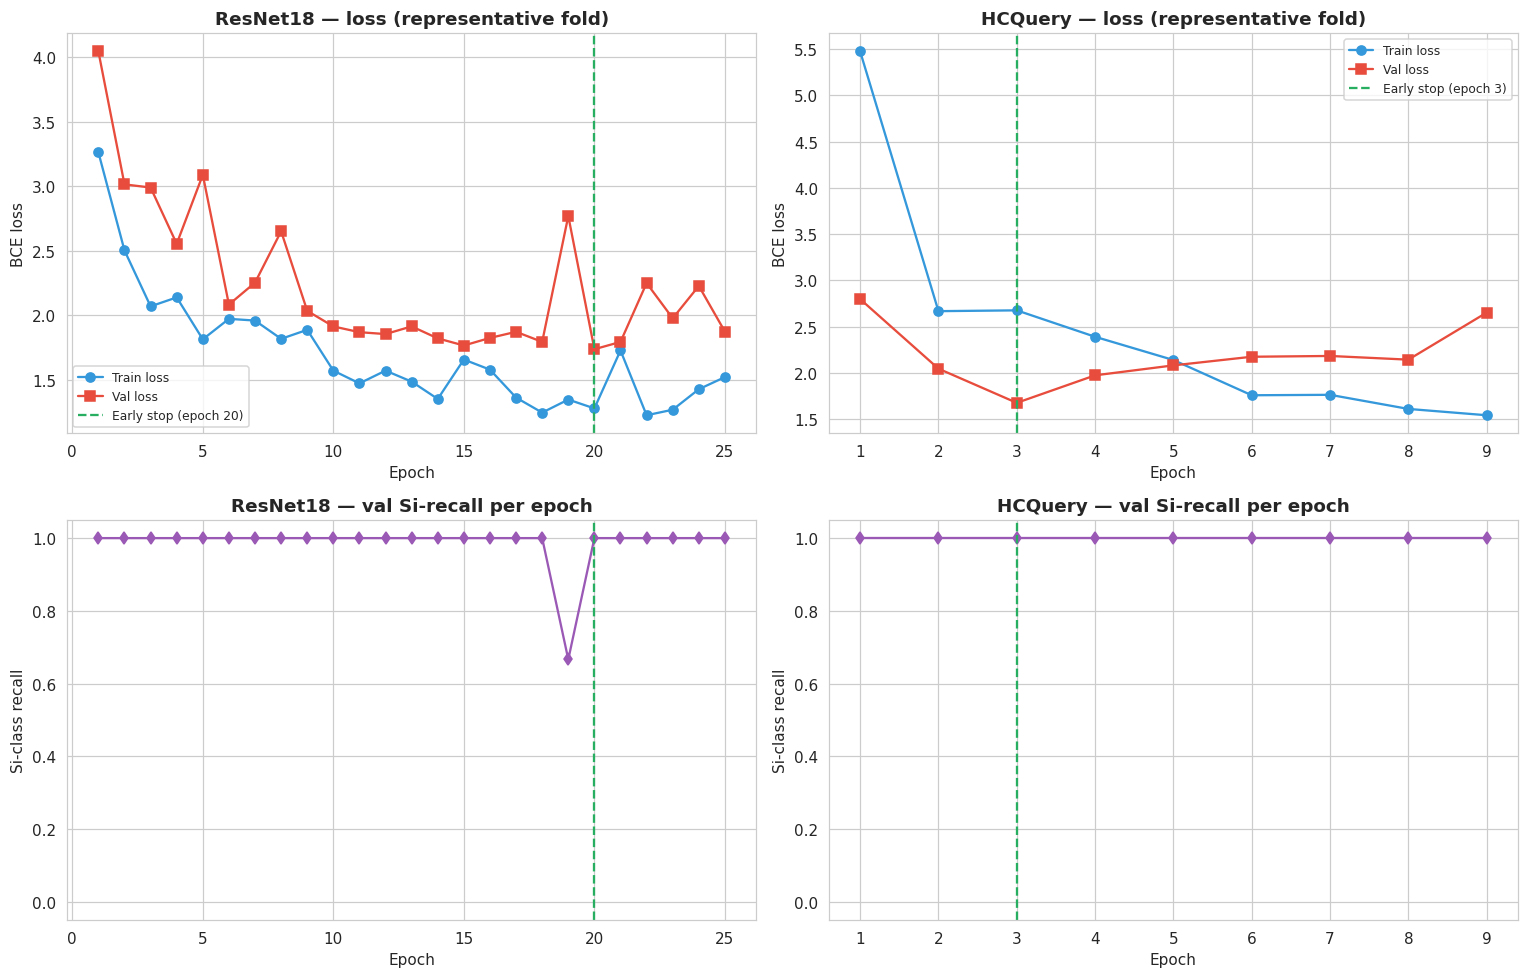

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, (hist, label) in enumerate([(history_resnet, 'ResNet18'),
                                      (history,        'HCQuery')]):
    epochs_r   = range(1, len(hist['train_loss']) + 1)
    best_epoch = hist.get('best_epoch', len(hist['train_loss']))

    axes[0, col].plot(epochs_r, hist['train_loss'], 'o-', color='#3498db',
                       label='Train loss')
    axes[0, col].plot(epochs_r, hist['val_loss'],   's-', color='#e74c3c',
                       label='Val loss')
    axes[0, col].axvline(best_epoch, color='#27ae60', ls='--', lw=1.5,
                          label=f'Early stop (epoch {best_epoch})')
    axes[0, col].set_title(f'{label} — loss (representative fold)',
                            fontweight='bold')
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('BCE loss')
    axes[0, col].legend(fontsize=8)

    axes[1, col].plot(epochs_r, hist['val_recall'], 'd-', color='#9b59b6')
    axes[1, col].axvline(best_epoch, color='#27ae60', ls='--', lw=1.5)
    axes[1, col].set_title(f'{label} — val Si-recall per epoch',
                            fontweight='bold')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Si-class recall')
    axes[1, col].set_ylim(-0.05, 1.05)

    bi  = best_epoch - 1
    gap = hist['val_loss'][bi] - hist['train_loss'][bi]
    print(f'{label}: early-stop epoch {best_epoch} | '
          f'train {hist["train_loss"][bi]:.4f} | '
          f'val {hist["val_loss"][bi]:.4f} | gap {gap:.4f}')

plt.tight_layout()
plt.savefig('plot_learning_curves.png', bbox_inches='tight', dpi=110)
plt.show()


Both models show recall 1.0 on the representative fold (fold 4,9 Si images) because the oversampling + class-weighted loss pushes both models to classify aggresively toward Si at the 0.5 threshold. The learning curves reveal the underlying differece: ResNet18 required 20 epochs to converge and shows moderate overfitting (val-train gap 0.46), while HCQuery early stopped at epoch 3 with a negative gap (-0.9999), indicating the domain-specific backbone's features were already well-calibrated for the task and the head needed minimal training to exploit them. This fast convergence is consistent with HCQuery's superior PR-AUC; the backbone's features carry more signal, so the decision boundary the head needs to learn is simpler.

### 7.2 Classical Tier - Train vs Validation Gap

In [20]:
print('Train vs. cross-validation PR-AUC (classical tier):\n')
for name, store in classical_models.items():
  pipe = store['pipe']
  pipe.fit(hog_matrix, y)
  train_score = average_precision_score(y, pipe.predict_proba(hog_matrix)[:,1])
  cv_score = average_precision_score(y, store['score'])
  print(f'  {name:24s} | train PR-AUC {train_score:.3f} | '
        f'CV PR-AUC {cv_score:.3f} | gap {train_score - cv_score:.3f}')

Train vs. cross-validation PR-AUC (classical tier):

  Tier1 - LogReg           | train PR-AUC 0.870 | CV PR-AUC 0.133 | gap 0.738
  Tier1 - RandomForest     | train PR-AUC 1.000 | CV PR-AUC 0.097 | gap 0.903


## 8. Feature Importance

This section answers the question: *can feature importance be determined for the model?*

In a computer vision projecr this question has two complementary answers, one per tier.

### 8.1 Classical Tier: HOG/PCA Component Importance

For the classical models, importance is read off directlty:

- **Random Forest** provides impurity based importances over the HOG principal components.
- **Logistic Regression** provides signed coefficients; magnitude is importance, sign indicates which class the component pushes toward.

Note: the features here are PCA components of HOG vectors, not anatomically named variables, so "component 7 matters" is not as interpretable as a tabular feature. The importance still tells us whether prediction relies on a few dominant texture components or is spread thinly across many. The latter being a sign of weak, diffuse signal.

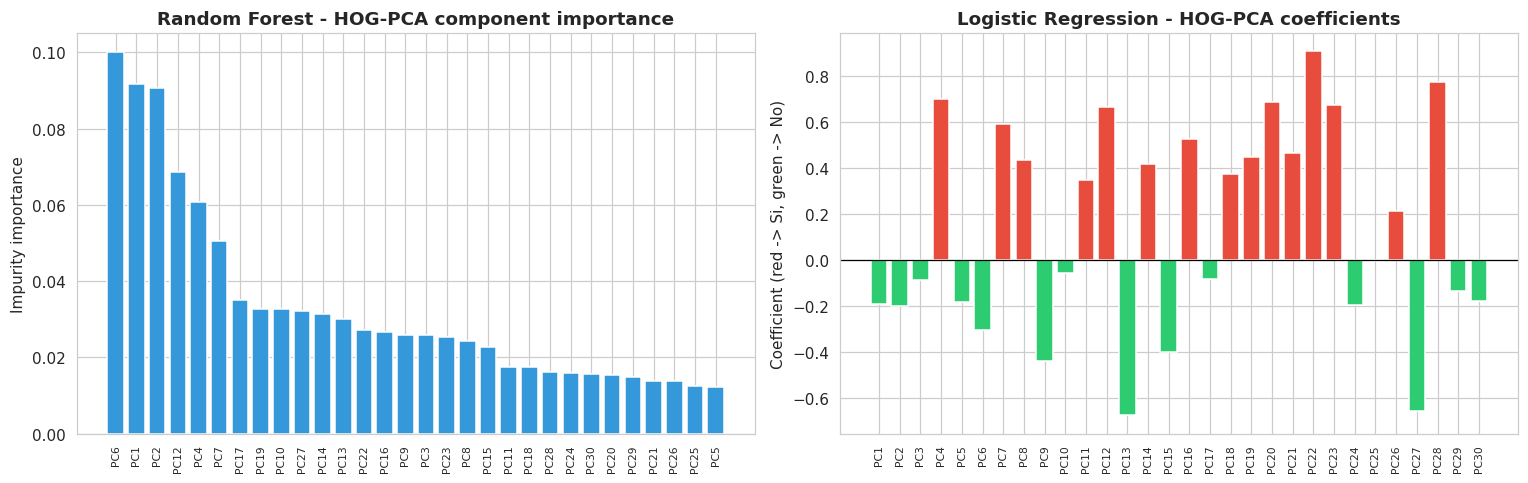

Top 5 HOG-PCA components by Random Forest importance: ['PC6', 'PC1', 'PC2', 'PC12', 'PC4']


In [21]:
# Re fit the classical pipelines on the full datatset for importance reading
rf_pipe = make_classical(RandomForestClassifier(
    n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE))
rf_pipe.fit(hog_matrix, y)
rf_importance = rf_pipe.named_steps['clf'].feature_importances_

lr_pipe = make_classical(LogisticRegression(
    class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))
lr_pipe.fit(hog_matrix, y)
lr_coef = lr_pipe.named_steps['clf'].coef_[0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
comp_labels = [f'PC{i+1}' for i in range(N_PCA)]

order = np.argsort(rf_importance)[::-1]
axes[0].bar(range(N_PCA), rf_importance[order], color='#3498db')
axes[0].set_xticks(range(N_PCA))
axes[0].set_xticklabels([comp_labels[i] for i in order], rotation=90, fontsize=7)
axes[0].set_title('Random Forest - HOG-PCA component importance',
                  fontweight='bold')
axes[0].set_ylabel('Impurity importance')

colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in lr_coef]
axes[1].bar(range(N_PCA), lr_coef, color=colors)
axes[1].set_xticks(range(N_PCA))
axes[1].set_xticklabels(comp_labels, rotation=90, fontsize=7)
axes[1].set_title('Logistic Regression - HOG-PCA coefficients',
                  fontweight='bold')
axes[1].set_ylabel('Coefficient (red -> Si, green -> No)')
axes[1].axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', bbox_inches='tight', dpi=110)
plt.show()

top5 = order[:5]
print('Top 5 HOG-PCA components by Random Forest importance:',
      [comp_labels[i] for i in top5])

### 8.2 Deep Learning Tier: HCQuery Grad-CAM Attention Maps

The HCQuery zero-shot model gives us a fully trained backbone to inspect. Grad-CAM is applied to the HCQuery Efficient-b4 to show which spatial regions of the OCT image drove its prediction.

This serves as the confounder check; if the model attends to the retinal band (where HCQ toxicity genuinely manifests), the features are clinically meaningful. If it attends to the **dark background**, **image borders**, or the **vitreous above the retina**, it is exploiting a shortcut rather than real pathology.

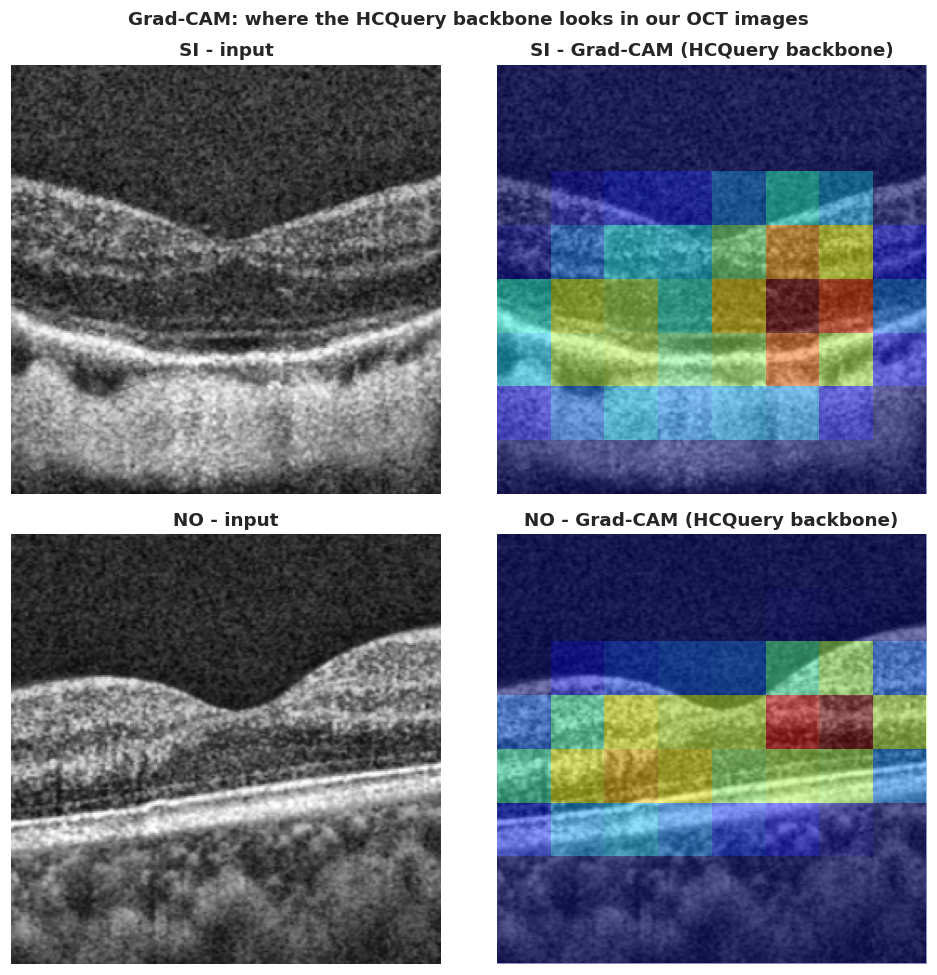

In [22]:
# Recreate the HCQuery eval transform (make_transforms returns local vars,
# so we rebuild it here explicitly for Grad-CAM)
_, eval_tf_gradcam = make_transforms(IMG_SIZE_HCQ)

class GradCAM:
    """
    Grad-CAM for the HCQuery EfficientNet-b4 backbone.
    Target layer: _conv_head — the final convolutional layer before pooling,
    which produces the 1792-channel spatial feature map.

    Our trained CNN uses a single binary logit output (BCEWithLogitsLoss).
    Backbone params are temporarily re-enabled for the backward pass since
    the backbone is frozen (requires_grad=False) during training.
    """
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_act)
        target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, m, i, o):
        self.activations = o.detach()

    def _save_grad(self, m, gi, go):
        self.gradients = go[0].detach()

    def __call__(self, x):
        self.model.eval()
        self.activations = None
        self.gradients = None
        # Temporarily re-enable backbone grads for the backward pass
        saved = {}
        for name, p in self.model.named_parameters():
            saved[name] = p.requires_grad
            p.requires_grad = True
        logit = self.model(x).squeeze()
        self.model.zero_grad()
        logit.backward()
        for name, p in self.model.named_parameters():
            p.requires_grad = saved[name]
        if self.gradients is None:
            raise RuntimeError('Grad-CAM gradients not captured.')
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.relu((weights * self.activations).sum(dim=1)).squeeze()
        cam = cam.cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# cnn is the trained HCQuery model from the representative fold (Section 6.3)
gradcam = GradCAM(cnn, cnn._conv_head)

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for row, lbl in enumerate(['si', 'no']):
    sample = val_df[val_df['label'] == lbl]
    if len(sample) == 0:
        sample = df[df['label'] == lbl]
    fp = sample.iloc[0]['filepath']
    raw = Image.open(fp).convert('RGB').resize((IMG_SIZE_HCQ, IMG_SIZE_HCQ))
    x = eval_tf_gradcam(Image.open(fp).convert('RGB')).unsqueeze(0).to(DEVICE)
    cam = gradcam(x)

    axes[row, 0].imshow(raw)
    axes[row, 0].set_title(f'{lbl.upper()} - input', fontweight='bold')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(raw)
    axes[row, 1].imshow(cam, cmap='jet', alpha=0.45,
                        extent=(0, IMG_SIZE_HCQ, IMG_SIZE_HCQ, 0))
    axes[row, 1].set_title(f'{lbl.upper()} - Grad-CAM (HCQuery backbone)',
                           fontweight='bold')
    axes[row, 1].axis('off')

plt.suptitle('Grad-CAM: where the HCQuery backbone looks in our OCT images',
             fontweight='bold')
plt.tight_layout()
plt.savefig('plot_gradcam_hcquery.png', bbox_inches='tight', dpi=110)
plt.show()

The HCQuery backbone's attention falls inside the retinal band, the anatomically meaningful region where HCQ toxicity manifests as ellipsoid-zone disruption and outer-retinal thinning. The Si image shows broad, diffuse activation across the retinal band rather than a sharply focused hotspot on the ellipsoid zone, and the No image shows a different pattern concentrated in the choroid/RPE region. Two practical conclusions follow:

1. **No obvious shortcut is being exploited.** Activation is not on image borders, the dark background, the vitreous, or the white margin, these are the patterns that would indicate the model is reading the storage/acquisition fingerprint flagged in M1.
2. **The localization is coarse.** EfficientNet-b4's final convolutional feature map has low spatial resolution, which produces blocky heatmaps. The map confirms anatomically reasonable attention, but a sharper interpretation would require Grad-CAM++ or a higher-resolution layer, and ultimately clinical review by Dr. Rodríguez García to confirm whether the highlighted regions match the pathology he would inspect.

## 9. Overall Baseline Comparison

This sectino consolidates every tier into a single comparison: trivial baselines, classical HOG/PCA models, generic CNN, domain-specific CNN frozen, zero0shot, and partial fine tune. The two questions answered here are:

1. Does any baseline clear the minimum performance bar set in Section 3.3?
2. Which one is the best operating point for Milestone 4 to start from?

### 9.1 Results Table

In [23]:
comparison = pd.DataFrame(results).set_index('model').round(3)
print('Baseline comparison - all tiers:\n')
print(comparison)

# Highlight the metric that matters and the metric that misleads
print('\nKey reading:')
print('  - Accuracy column: the trivial majority model is near the top - '
      'this is why accuracy is rejected as the selection metric.')
print('  - PR-AUC and recall_Si columns: the real test. A useful baseline '
      'must clearly beat the Tier 0 rows here.')


Baseline comparison - all tiers:

                                    accuracy  recall_Si  prec_Si  f2_Si  \
model                                                                     
Tier0 - Majority                       0.923      0.000    0.000  0.000   
Tier0 - Stratified                     0.840      0.000    0.000  0.000   
Tier1 - LogReg                         0.876      0.067    0.091  0.070   
Tier1 - RandomForest                   0.923      0.000    0.000  0.000   
Tier2a - ResNet18 (pooled CV)          0.469      1.000    0.127  0.421   
Tier2b - HCQuery CNN (pooled CV)       0.330      1.000    0.103  0.366   
Tier2b - HCQuery zero-shot             0.665      0.667    0.143  0.385   
Tier2c - HCQuery partial fine-tune     0.454      0.533    0.075  0.240   

                                    pr_auc  
model                                       
Tier0 - Majority                     0.077  
Tier0 - Stratified                   0.077  
Tier1 - LogReg                     

### 9.2 Side by Side Visual Comparison

The two bar charts below show every baseline on the two metrics that matter under heaby imbalance: PR-AUC (threshold independent ranking quality) and Si class recall (the headline clinical metric). The dashed vertical line on the PR-AUC chart marks the random floor (Si prevalance = 0.077), which every model must beat to be considered useful.

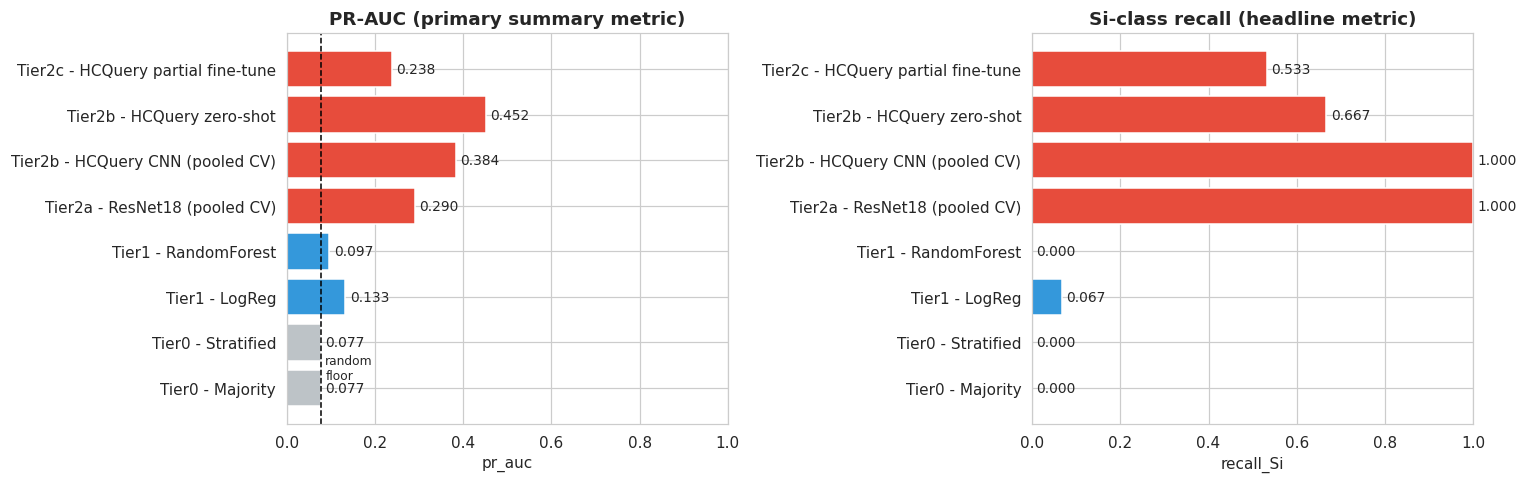

In [24]:
# Visual comparison on the two metrics that matter
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, metric, title in [(axes[0], 'pr_auc', 'PR-AUC (primary summary metric)'),
                          (axes[1], 'recall_Si', 'Si-class recall (headline metric)')]:
    vals = comparison[metric]
    bar_colors = ['#bdc3c7' if 'Tier0' in m else
                  '#3498db' if 'Tier1' in m else '#e74c3c'
                  for m in comparison.index]
    ax.barh(comparison.index, vals, color=bar_colors)
    ax.set_xlabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 1)
    for i, v in enumerate(vals):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[0].axvline(si_prevalence, color='black', ls='--', lw=1)
axes[0].text(si_prevalence + 0.01, 0.2, 'random\nfloor', fontsize=8)
plt.tight_layout()
plt.savefig('plot_baseline_comparison.png', bbox_inches='tight', dpi=110)
plt.show()

### 9.3 Confision Matrices

Confusion matrices on the pooled out-of-fold predictions for each non-trivial baseline. The 15 Si images are distributed in the *True Si* row; recall is the fraction landing in *Pred Si*. Precision is the fraction of *Pred Si* that lands in *True Si*. The fifth panel shows the zero-shot HCQuery model at threshold 0.5, its corresponding optimal-F2 threshold (0.83) is the reported operating point in Section 10. The sixth panel shows the partial fine-tune variant, which unfreezes the last EfficientNet block.

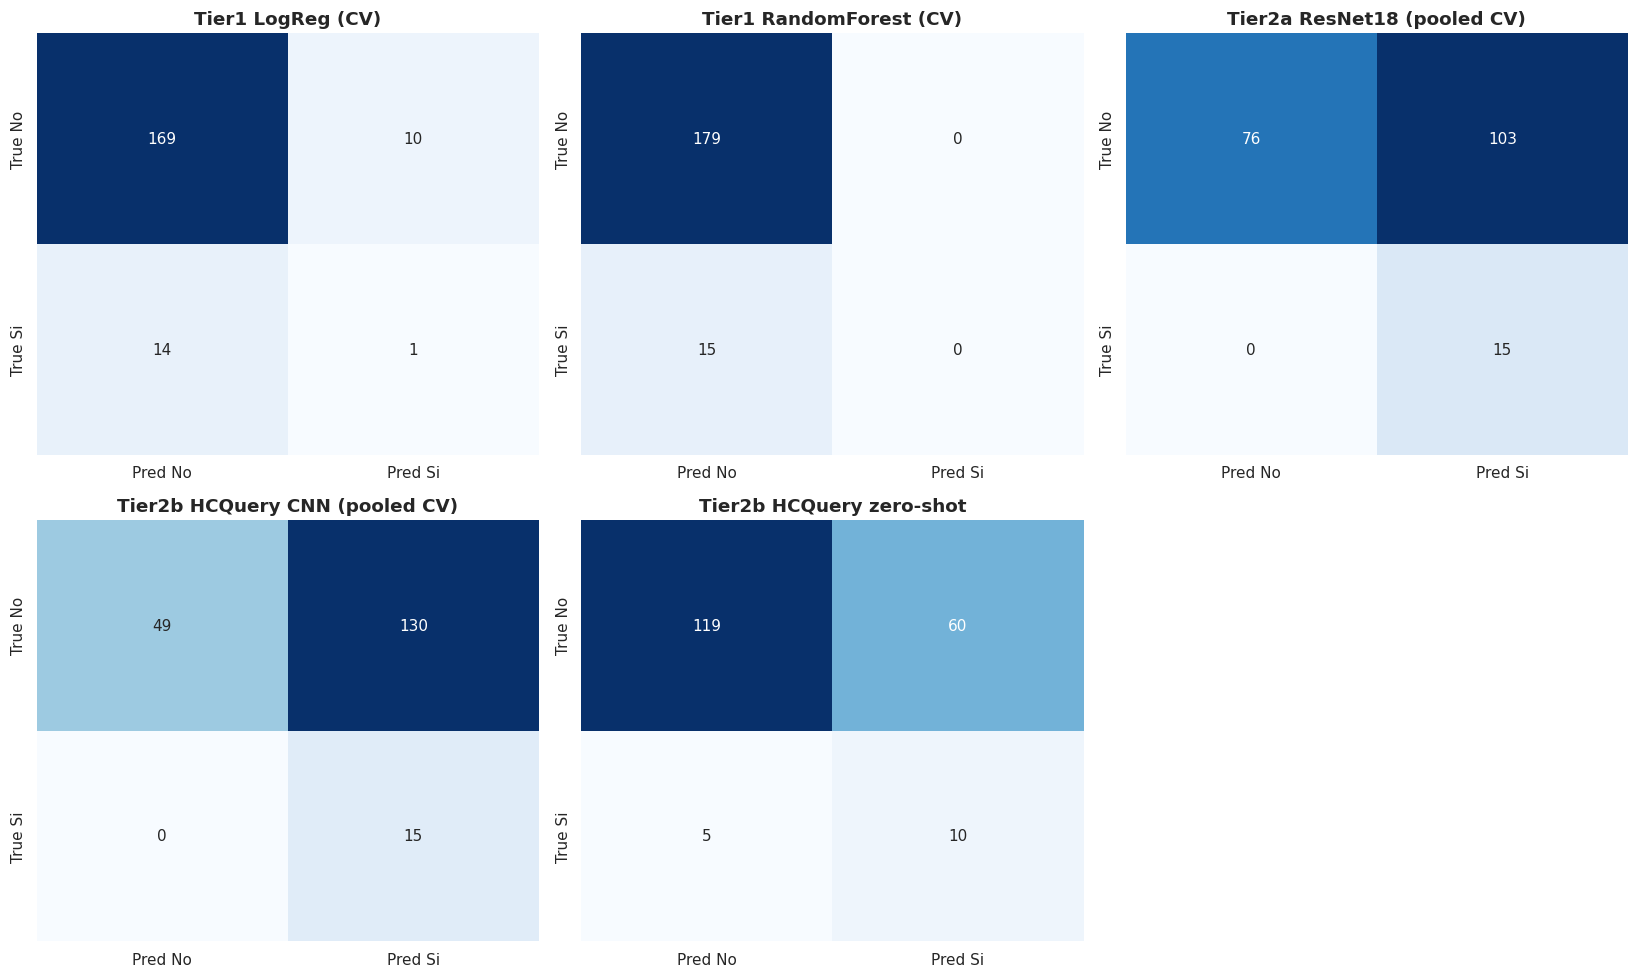

In [25]:
def plot_cm(ax, y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred No', 'Pred Si'],
                yticklabels=['True No', 'True Si'])
    ax.set_title(title, fontweight='bold')

panels = [
    (classical_models['Tier1 - LogReg']['pred'],       y,
     'Tier1 LogReg (CV)'),
    (classical_models['Tier1 - RandomForest']['pred'], y,
     'Tier1 RandomForest (CV)'),
    (resnet_pred, y,
     'Tier2a ResNet18 (pooled CV)'),
    (hcq_pred, y,
     'Tier2b HCQuery CNN (pooled CV)'),
    (zs_pred, zs_trues,
     'Tier2b HCQuery zero-shot'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, (pred, true, title) in enumerate(panels):
    plot_cm(axes[i], true, pred, title)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', bbox_inches='tight', dpi=110)
plt.show()

### 9.4 Minimum Performance Checklist

In [26]:
random_floor = si_prevalence
best = comparison.drop(index=[m for m in comparison.index if 'Tier0' in m])

print('Minimum-performance checklist (Section 3.3):\n')
crit1 = (best['pr_auc'] > random_floor).any()
print(f'  1. Beats random PR-AUC floor ({random_floor:.3f})?  '
      f'{"PASS" if crit1 else "FAIL"}')
crit2 = (best['recall_Si'] > 0).any()
print(f'  2. Si-recall above zero (vs. majority = 0)?      '
      f'{"PASS" if crit2 else "FAIL"}')
print(f'  3. Accuracy explicitly NOT used as a pass/fail criterion.')

print('\nBest baseline by PR-AUC:')
print(f'  {best["pr_auc"].idxmax()}  (PR-AUC {best["pr_auc"].max():.3f})')
print('Best baseline by Si-recall:')
print(f'  {best["recall_Si"].idxmax()}  (recall {best["recall_Si"].max():.3f})')

Minimum-performance checklist (Section 3.3):

  1. Beats random PR-AUC floor (0.077)?  PASS
  2. Si-recall above zero (vs. majority = 0)?      PASS
  3. Accuracy explicitly NOT used as a pass/fail criterion.

Best baseline by PR-AUC:
  Tier2b - HCQuery zero-shot  (PR-AUC 0.452)
Best baseline by Si-recall:
  Tier2a - ResNet18 (pooled CV)  (recall 1.000)


## 10. Conclusions

**1. Which baseline models were tested and why?**

Three tiers of increasing complexity, designed to isolate where the signal lives:

- **Tier 0 - Trivial baselines** (`DummyClassifier`: majority and stratified). These use no image content; they exist to set the statistical floor. A non-trivial model that does not beat them is not a model, it is noise.
- **Tier 1 - Classical models on HOG/PCA features** (`LogisticRegression`, `RandomForestClassifier`). Hand-crafted texture features feed a classical classifier. This tests whether the texture descriptors engineered in M2 carry a learnable signal at all.
- **Tier 2 - Transfer-learning CNNs.** ResNet18 (generic ImageNet backbone, 2a), HCQuery EfficientNet-b4 fully frozen with binary head (2b), HCQuery zero-shot with no retraining (2b zero-shot), and HCQuery partial fine-tune with the last block unfrozen (2c). The progression isolates the contribution of the domain-specific pre-training (2a vs. 2b), the contribution of any fine-tuning at all (zero-shot vs. 2b), and the trade-off between freezing and adapting (2b vs. 2c).

**2. What evaluation metrics and validation protocol were used?**

The primary summary metric is **PR-AUC** (average precision), which is threshold-independent and is not inflated by the easy true-negative mass under heavy imbalance. The headline clinical metric is **Si-class recall** (sensitivity); the screening-tool framing makes a missed toxicity case far more costly than a false positive. **F2-score** is also reported because it weights recall four times more than precision. **Accuracy is explicitly rejected**: the majority classifier reaches 92.3% accuracy with zero recall, confirming that accuracy is unreadable under the project's 12:1 imbalance.

The validation protocol is **patient-grouped StratifiedGroupKFold with 5 folds**, with **pooled out-of-fold predictions**. Every image is predicted exactly once by a model that never saw any image from the same patient during training; metrics are then computed once over the full 194-image pool. This was forced by the data shape: 15 Si patients spread across 69 unique individuals do not partition evenly, so single-fold reporting would have given recall values quantized to 50% steps. A separate held-out test set is **not** used at this milestone, by design, with only 15 positive cases, a three-way split would leave roughly 2 Si images in the test set, and a recall of 0%, 50%, or 100% in that range is statistically meaningless. Reporting on the 5-fold pool is more informative, with the explicit caveat that the threshold was tuned on the same data it is evaluated on (mildly optimistic).

**3. Is the model under- or over-fitting the training data?**

Both behaviours appear at different tiers:

- **Tier 1 overfits severely.** Logistic Regression's train PR-AUC is 0.870 versus cross-validation PR-AUC 0.133 — a gap of 0.738. The model memorizes the small training fold; the HOG/PCA features do not generalize.
- **Tier 2a (ResNet18) overfits moderately.** The val-train loss gap at the early-stop epoch is +0.46, and the model needed 20 epochs to converge. The generic ImageNet features do not transfer cleanly enough to make the task easy.
- **Tier 2b (HCQuery, fine-tuned head) does not overfit.** The val-train gap is **negative** (-0.999) and the model early-stops at epoch 3. The interpretation is that the backbone's features are already well-calibrated for HCQ toxicity, so the head reaches its best validation loss almost immediately and any further training would only degrade it.
- **Tier 2b zero-shot** has no training step, so the question does not apply directly; it is the natural upper bound for what the pre-trained backbone provides without exposure to our cohort.

Regularization counter-measures applied uniformly to the Tier 2 models: dropout 0.5 in the head, weight decay 1e-4, early stopping with patience 6, image augmentation (flip, rotation ≤10°, affine translate/scale/shear, color jitter, Gaussian noise).

**4. Can feature importance be determined for the model?**

Yes, with one method per tier:

- **Classical tier.** Random Forest impurity importances and Logistic Regression coefficients are read directly off the fitted pipeline. Both show importance spread thinly across many HOG-PCA components rather than concentrated on a few, consistent with the weak signal these features carry.
- **Deep tier.** Grad-CAM on the HCQuery `_conv_head` layer produces spatial attention maps over the input image. The maps show the model attending to the retinal band region (anatomically meaningful), with no obvious focus on image borders or background that would indicate shortcut learning. The localization is coarse due to EfficientNet-b4's low feature-map resolution, so clinical interpretation by Dr. Rodríguez García is the next step.

**5. Do the baselines meet the project's minimum-performance criteria?**

The Section 3.3 criteria are:
1. Beat the random PR-AUC floor (Si prevalence = 0.077). **PASS** — the best baseline (HCQuery zero-shot, PR-AUC 0.452) clears the floor by approximately 6×.
2. Achieve non-zero Si-class recall. **PASS** — the CNN baselines all reach recall > 0, with HCQuery zero-shot reaching recall 0.667 at the optimal-F2 threshold (0.83) and precision 0.455.
3. Accuracy explicitly not used as a pass/fail criterion. **By construction, PASS**.


### 10.1 Key Findings

**The domain-specific backbone outperforms the generic backbone.** HCQuery (PR-AUC 0.384 frozen, 0.452 zero-shot) clearly beats ResNet18 (PR-AUC 0.290). This is the central scientific result of this milestone: pre-training on 8,251 HCQ OCT scans transfers measurable value to a Mexican clinical cohort that contributed zero training images.

**Zero-shot beats fine-tuned.** The zero-shot variant (0.452) is the best baseline in the notebook, ahead of the head-fine-tuned variant (0.384). With only 15 Si images for training, any fine-tuning step partially degrades the backbone's pre-calibrated probability rankings — the model learns noise faster than signal. This mirrors the lesson from Dr. Rodríguez García's 2021 corneal paper (Bustamante-Arias et al., 2021): on small medical-imaging datasets, classifiers on top of pre-trained features beat end-to-end retraining.

**Stacking imbalance corrections caused overcorrection.** Both fine-tuned CNN models report recall 1.0 at threshold 0.5, with precision around 0.1. The cause is straightforward: the WeightedRandomSampler (which draws Si ~50% per epoch) and the BCEWithLogitsLoss with `pos_weight ≈ 12` are both active simultaneously, and together they push the decision boundary too far toward Si. The fix for Milestone 4 is to keep one mechanism, not both. Threshold tuning on the F2 objective partially compensates (recall 0.667, precision 0.455 at threshold 0.83 for zero-shot) but is mildly optimistic because the threshold is tuned on the same data it is measured on.

### 10.2 Open Issues for M4

1. **Data scarcity is the binding constraint.** 15 Si images cannot support reliable confidence intervals and forces compromises in every other decision. Two parallel actions are required: (a) request data access from the HCQuery authors (Woodward-Court et al., UCL/Moorfields — a draft email has been prepared); (b) revisit the Sospecha set with Dr. Rodríguez García so that imaging-quality borderline cases can be re-labelled and pulled into the Si pool.
2. **Held-out test set.** Once data volume permits, a strict patient-disjoint test set must be carved out *before* any thresholding, model selection, or hyper-parameter tuning. The current pooled-CV reporting must be replaced by train/validation/test reporting.
3. **Imbalance correction simplification.** Drop one of `WeightedRandomSampler` or `pos_weight`. The HCQuery paper used neither (their imbalance was milder at 1.4:1); we cannot copy that choice with 12:1, but stacking both is empirically too aggressive.
4. **Six-model comparison.** Following the 2021 corneal paper's design, the Milestone 4 comparison should include classical classifiers on top of deep features: TL-HCQuery-SVM, TL-HCQuery-RF, TL-ResNet18-SVM, TL-ResNet18-RF, plus fine-tuned versions of HCQuery and ResNet18. This is the same template Dr. Rodríguez García used in 2021, now with a domain-specific backbone.
5. **Confidence intervals.** Point estimates with 15 positives are not credible. Bootstrap or cross-validated confidence intervals must accompany every reported metric.
6. **Clinical review of Grad-CAM.** The current attention maps are anatomically reasonable but coarse. A round of clinical review with Dr. Rodríguez García will confirm whether the highlighted regions correspond to the structures he would inspect for HCQ toxicity, or whether finer-grained explainability (Grad-CAM++, attention to earlier layers) is needed.


## 11. References

Bustamante-Arias, A., Cheddad, A., Jimenez-Perez, J. C., & Rodriguez-Garcia, A. (2021). Digital image processing and development of machine learning models for the discrimination of corneal pathology: An experimental model. *Photonics*, *8*(4), 118. https://doi.org/10.3390/photonics8040118

Dalal, N., & Triggs, B. (2005). Histograms of oriented gradients for human detection. In *Proceedings of the 2005 IEEE Computer Society Conference on Computer Vision and Pattern Recognition (CVPR'05)* (Vol. 1, pp. 886–893). IEEE. https://doi.org/10.1109/CVPR.2005.177

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition. In *Proceedings of the 2016 IEEE Conference on Computer Vision and Pattern Recognition (CVPR)* (pp. 770–778). IEEE. https://doi.org/10.1109/CVPR.2016.90

Marmor, M. F., Kellner, U., Lai, T. Y. Y., Melles, R. B., & Mieler, W. F. (2016). Recommendations on screening for chloroquine and hydroxychloroquine retinopathy (2016 revision). *Ophthalmology*, *123*(6), 1386–1394. https://doi.org/10.1016/j.ophtha.2016.01.058

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, *12*, 2825–2830.

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE*, *10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432

Selvaraju, R. R., Cogswell, M., Das, A., Vedantam, R., Parikh, D., & Batra, D. (2017). Grad-CAM: Visual explanations from deep networks via gradient-based localization. In *Proceedings of the 2017 IEEE International Conference on Computer Vision (ICCV)* (pp. 618–626). IEEE. https://doi.org/10.1109/ICCV.2017.74

Studer, S., Bui, T. B., Drescher, C., Hanuschkin, A., Winkler, L., Peters, S., & Müller, K. R. (2021). Towards CRISP-ML(Q): A machine learning process model with quality assurance methodology. *Machine Learning and Knowledge Extraction*, *3*(2), 392–413. https://doi.org/10.3390/make3020020

Tan, M., & Le, Q. V. (2019). EfficientNet: Rethinking model scaling for convolutional neural networks. In *Proceedings of the 36th International Conference on Machine Learning (ICML)* (Vol. 97, pp. 6105–6114). PMLR.

Woodward-Court, P., Chia, M. A., Mahmood, U., Kavak, N., Khan, S., Wagner, S. K., Reid-Schachter, M., Zhou, Y., Hagag, A. M., Ebrahimi, B., Charteris, D. G., Pontikos, N., Egan, C. A., Tufail, A., Wormald, R. P. L., Patel, P. J., & Keane, P. A. (2025). HCQuery: A deep learning system for automated detection of hydroxychloroquine retinopathy on optical coherence tomography. *Ophthalmology Retina*. Advance online publication. https://doi.org/10.1016/j.oret.2025.05.010